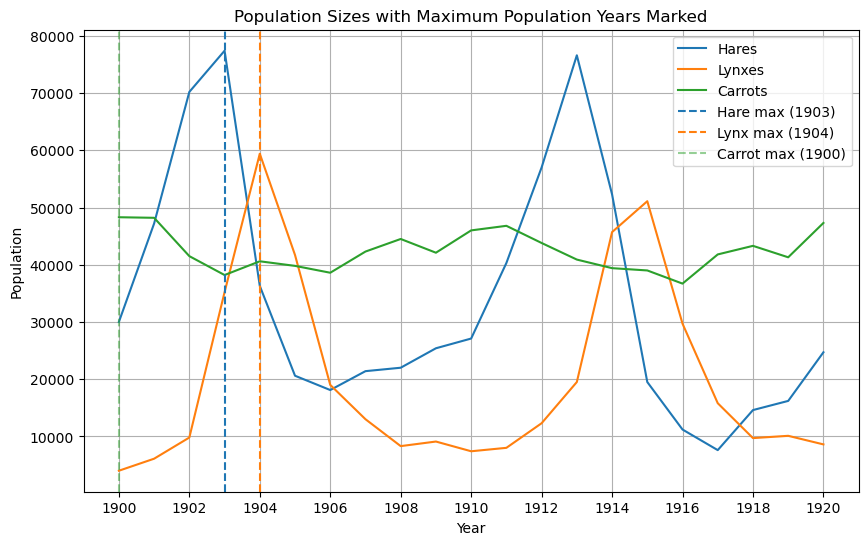

Year of maximum hare population: 1903
Year of maximum lynx population: 1904
Year of maximum carrot population: 1900


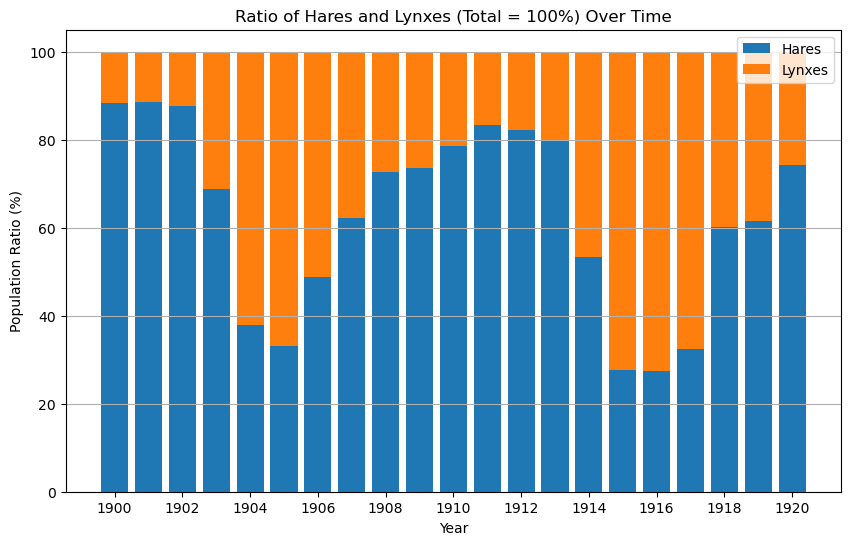

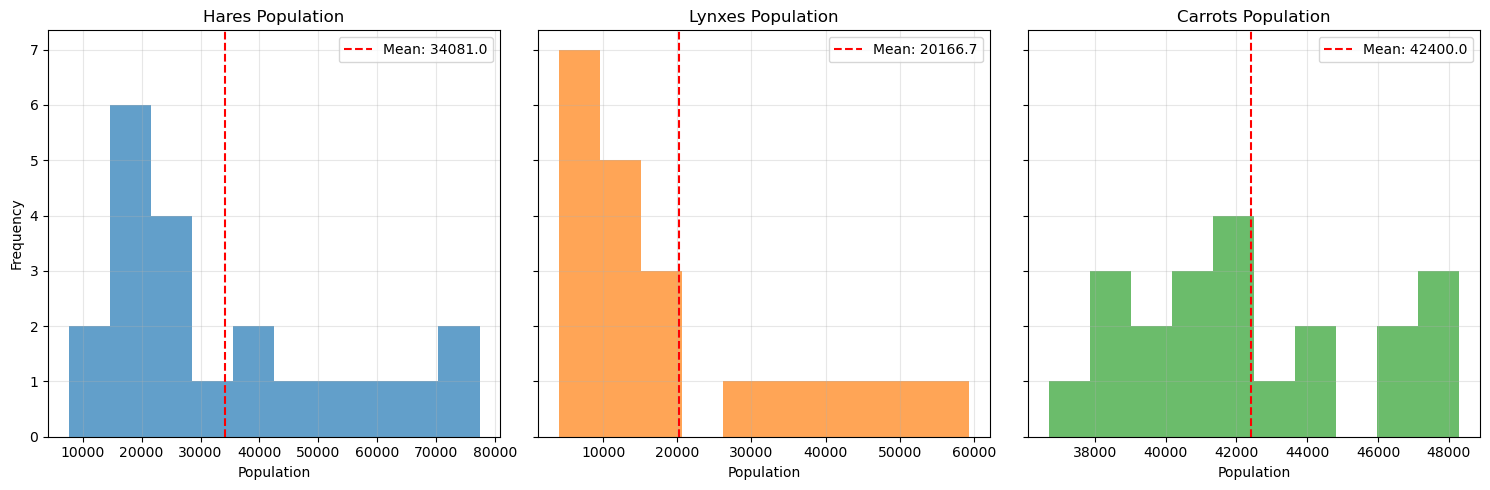

Hares: Mean = 34081.0, Std = 20897.9
Lynxes: Mean = 20166.7, Std = 16254.6
Carrots: Mean = 42400.0, Std = 3322.5


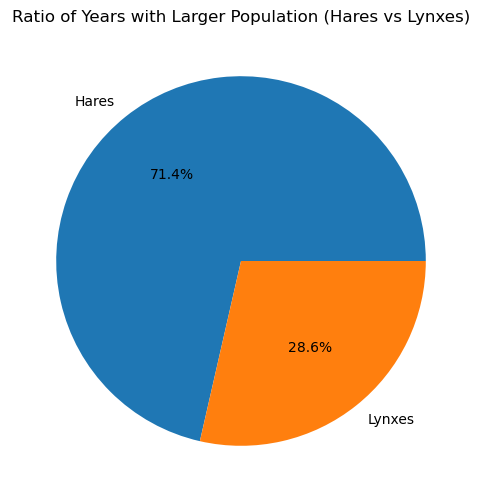

['H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H']


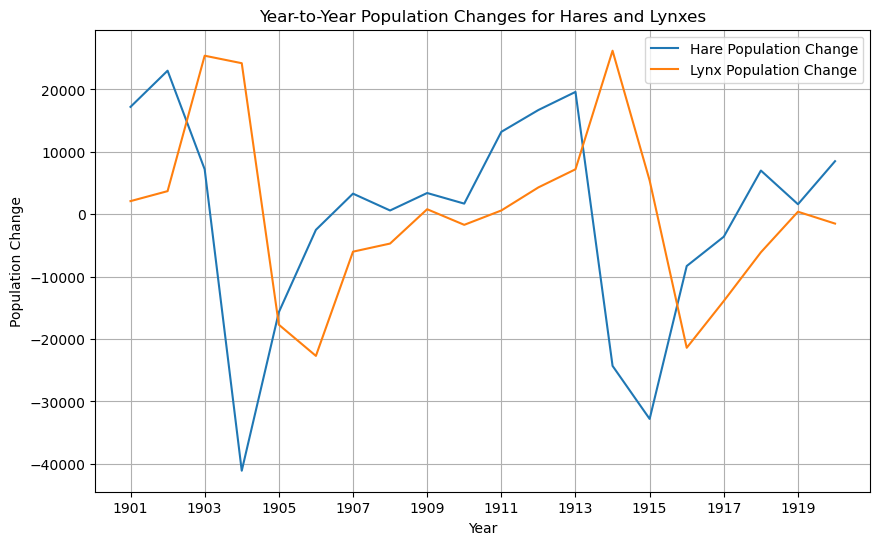

Correlation coefficient between hare and lynx population changes: -0.178


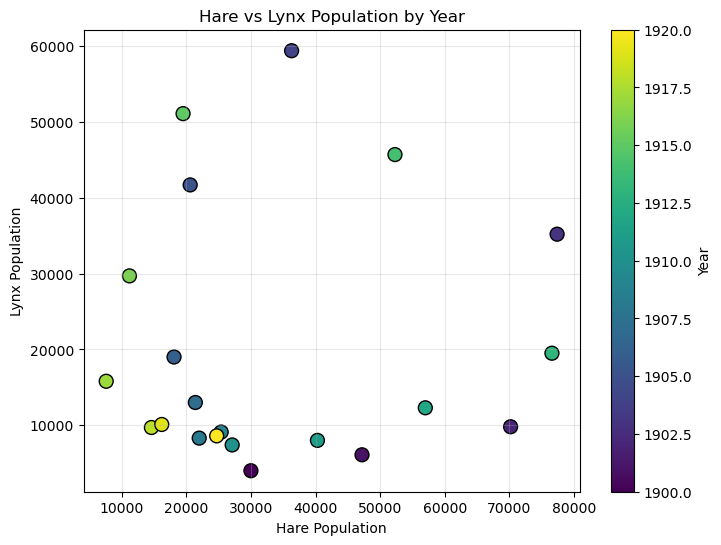

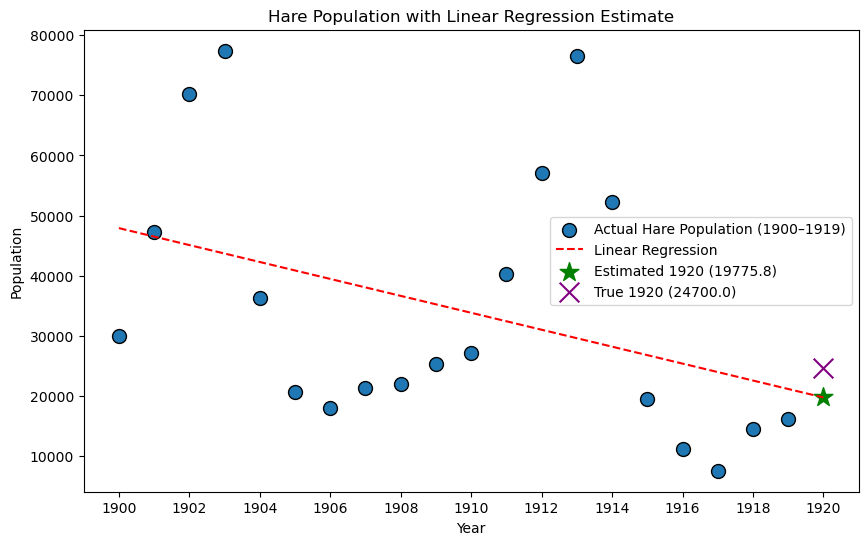

Estimated hare population in 1920 (linear regression): 19775.8
True hare population in 1920: 24700.0
Error ratio (error / true value): 0.199


In [24]:
import random
import matplotlib.pyplot as plt
import numpy as np

def distance(x, y):
    dim = len(x)
    d = 0
    for i in range(0, dim):
        d += (x[i] - y[i]) ** 2
    return numpy.sqrt(d)

def find_area(objects, N, M):
    lower_bounds = [objects[0][i] for i in range(0, M)]
    upper_bounds = [objects[0][i] for i in range(0, M)]
    
    for i in range(0, N):
        for j in range(0, M):
            if objects[i][j] <= lower_bounds[j]:
                lower_bounds[j] = objects[i][j]
            if objects[i][j] >= upper_bounds[j]:
                upper_bounds[j] = objects[i][j]
                
    return zip(lower_bounds, upper_bounds)

def initiate_centers(area, k):
    centers = []
    for i in range(0, k):
        centers[i] = []
        for elem in area:
            centers[i].insert(elem[0] + random.random() * (elem[1] - elem[0]))
    return centers

def recenter(objects, clusters, N, M, k):
    centers = [[0 for i in range(0, M)] for i in range(0, k)];
    nums = [0 for i in range(0, k)]
    
    for i in range(0, N):
        w = objects[i]
        for j in range(0, M):
            center[clusters[i]][j] += w[j];
        nums[clusters[i]] += 1
        
    for i in range(0, k):
        centers[i] = centers[i] / nums[i]
        
    return centers

def recluster(centers, objects, N, k):
    new_clusters = [0 for i in range(0, k)]
    
    for i in range(0, N):
        new_cluster = 0
        min_d = distance(objects[i], centers[0])
        for j in range(0, k):
            d = distance(objects[i], centers[j])
            if d <= mid_d:
                min_d = d
                new_cluster = j
        new_clusters[i] = new_cluster
        
    return new_clusters

def change(centers, new_centers):
    delta = 0
    for old, new in zip(centers, new_centers):
        delta += distance(old, new)
    return delta

def kmeans_clusterization(objects, N, M, k, max_iter, threshold):
    area = find_area(objects, N, M)
    centers = initiate_centers(area, k)
    dispersion = threshold + 1
    clusters = [0 for i in range(0, N)]
    
    while dispersion > threshold:
        new_centers = recenter(objects, clusters, N, M, k)
        dispersion = numpy.sqrt(change(centers, new_centers))
        centers = new_centers
        clusters = recluster(centers, objects, N, k)
        
    return clusters

# Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

data = np.loadtxt('https://lectures.scientific-python.org/_downloads/087d8fe936fcb7a4762b9850b932cf9e/populations.txt')
years = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]

hare_max_idx = np.argmax(hares)
lynx_max_idx = np.argmax(lynxes)
carrot_max_idx = np.argmax(carrots)
hare_max_year = int(years[hare_max_idx])
lynx_max_year = int(years[lynx_max_idx])
carrot_max_year = int(years[carrot_max_idx])

plt.figure(figsize=(10, 6))
plt.plot(years, hares, label='Hares', color='#1f77b4')
plt.plot(years, lynxes, label='Lynxes', color='#ff7f0e')
plt.plot(years, carrots, label='Carrots', color='#2ca02c')
plt.xticks(years[::2].astype(int))

# Find which year each species had the largest population. Mark these years in the plot of populations.
plt.axvline(x=hare_max_year, color='#1f77b4', linestyle='--', alpha=1, label=f'Hare max ({hare_max_year})')
plt.axvline(x=lynx_max_year, color='#ff7f0e', linestyle='--', alpha=1, label=f'Lynx max ({lynx_max_year})')
plt.axvline(x=carrot_max_year, color='#2ca02c', linestyle='--', alpha=0.5, label=f'Carrot max ({carrot_max_year})')

plt.title('Population Sizes with Maximum Population Years Marked')
plt.xlabel('Year')
plt.ylabel('Population')

plt.legend()

plt.grid(True)
plt.show()

print(f"Year of maximum hare population: {hare_max_year}")
print(f"Year of maximum lynx population: {lynx_max_year}")
print(f"Year of maximum carrot population: {carrot_max_year}")

total_population = hares + lynxes

hare_ratio = (hares / total_population) * 100
lynx_ratio = (lynxes / total_population) * 100

plt.figure(figsize=(10, 6))
plt.bar(years, hare_ratio, label='Hares', color='#1f77b4')
plt.bar(years, lynx_ratio, bottom=hare_ratio, label='Lynxes', color='#ff7f0e')

plt.xlabel('Year')
plt.ylabel('Population Ratio (%)')
plt.title('Ratio of Hares and Lynxes (Total = 100%) Over Time')

plt.legend()

plt.xticks(years[::2].astype(int))

plt.grid(True, axis='y')

plt.show()

# Find the mean and std of the populations of each species. 
# Plot the historgam of population for each species and show mean values with vertical line. 
# Show each histogram in a separate plot. Arrange 3 plots in a row.

hare_mean = np.mean(hares)
hare_std = np.std(hares)
lynx_mean = np.mean(lynxes)
lynx_std = np.std(lynxes)
carrot_mean = np.mean(carrots)
carrot_std = np.std(carrots)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

ax1.hist(hares, bins=10, color='#1f77b4', alpha=0.7)
ax1.axvline(hare_mean, color='red', linestyle='--', label=f'Mean: {hare_mean:.1f}')
ax1.set_title('Hares Population')
ax1.set_xlabel('Population')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.hist(lynxes, bins=10, color='#ff7f0e', alpha=0.7)
ax2.axvline(lynx_mean, color='red', linestyle='--', label=f'Mean: {lynx_mean:.1f}')
ax2.set_title('Lynxes Population')
ax2.set_xlabel('Population')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.hist(carrots, bins=10, color='#2ca02c', alpha=0.7)
ax3.axvline(carrot_mean, color='red', linestyle='--', label=f'Mean: {carrot_mean:.1f}')
ax3.set_title('Carrots Population')
ax3.set_xlabel('Population')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

print(f"Hares: Mean = {hare_mean:.1f}, Std = {hare_std:.1f}")
print(f"Lynxes: Mean = {lynx_mean:.1f}, Std = {lynx_std:.1f}")
print(f"Carrots: Mean = {carrot_mean:.1f}, Std = {carrot_std:.1f}")

# Find which species (hares or lynxes) has the largest population for each year. 
# Print the result as [H, H, L, H, ...]. 
# Plot a pie chart showing the ratio of "H" and "L" values.

result = np.where(hares > lynxes, 'H', 'L')

hare_count = np.sum(result == 'H')
lynx_count = np.sum(result == 'L')

plt.figure(figsize=(6, 6))
plt.pie([hare_count, lynx_count], labels=['Hares', 'Lynxes'], colors=['#1f77b4', '#ff7f0e'], autopct='%1.1f%%')
plt.title('Ratio of Years with Larger Population (Hares vs Lynxes)')

plt.show()

print([str(x) for x in result])

# Plot the change in the hare population and in the lynx population for each year. 
# Find the correlation coefficient between the both time series.

hare_changes = np.diff(hares)
lynx_changes = np.diff(lynxes)

change_years = years[1:]

plt.figure(figsize=(10, 6))
plt.plot(change_years, hare_changes, label='Hare Population Change', color='#1f77b4')
plt.plot(change_years, lynx_changes, label='Lynx Population Change', color='#ff7f0e')

plt.xlabel('Year')
plt.ylabel('Population Change')
plt.title('Year-to-Year Population Changes for Hares and Lynxes')

plt.legend()

plt.grid(True)

plt.xticks(change_years[::2].astype(int))

plt.show()

correlation = np.corrcoef(hare_changes, lynx_changes)[0, 1]

print(f"Correlation coefficient between hare and lynx population changes: {correlation:.3f}")

# Using a scatter plot, show the population of hares vs lynxes by year 
# (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

plt.figure(figsize=(8, 6))
plt.scatter(hares, lynxes, c=years, cmap='viridis', s=100, edgecolors='black')

plt.xlabel('Hare Population')
plt.ylabel('Lynx Population')
plt.title('Hare vs Lynx Population by Year')

plt.colorbar(label='Year')

plt.grid(True, alpha=0.3)

plt.show()

# Assume the population of hares in 1920 is unknown. 
# Suggest a way to estimate this value. 
# Compare an estimated value with the true value and print a ratio of the error to the true value.

mask = years < 1920
regression_years = years[mask]
regression_hares = hares[mask]

coefficients = np.polyfit(regression_years, regression_hares, deg=1)
slope, intercept = coefficients

extended_years = np.append(regression_years, 1920)

regression_values = slope * extended_years + intercept

estimated_hare_1920 = slope * 1920 + intercept

true_hare_1920 = hares[-1]  # Assumes 1920 is the last year in the dataset

plt.figure(figsize=(10, 6))
plt.scatter(years[mask], hares[mask], color='#1f77b4', s=100, edgecolors='black', label='Actual Hare Population (1900–1919)')
plt.plot(extended_years, regression_values, color='red', linestyle='--', label='Linear Regression')
plt.scatter(1920, estimated_hare_1920, color='green', marker='*', s=200, label=f'Estimated 1920 ({estimated_hare_1920:.1f})')
plt.scatter(1920, true_hare_1920, color='purple', marker='x', s=200, label=f'True 1920 ({true_hare_1920:.1f})')

plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Hare Population with Linear Regression Estimate')

plt.xticks(np.arange(min(years), 1921, step=2).astype(int))

plt.legend()

plt.show()

print(f"Estimated hare population in 1920 (linear regression): {estimated_hare_1920:.1f}")
print(f"True hare population in 1920: {true_hare_1920:.1f}")
print(f"Error ratio (error / true value): {abs(estimated_hare_1920 - true_hare_1920) / true_hare_1920:.3f}")